# Automated Detection of Teams of Players using IPL Jersey Identification
### Programming for Machine Learning and Data Science — Course Project (CMInDS, IIT Bombay)

Given an 800×600 cricket image, divide it into an **8×8 grid (64 cells)** and predict a label `0–10` for every cell (IPL franchise occupying that cell, or `0` = no team).

| Label | Team | | Label | Team |
|---|---|---|---|---|
| 0 | No team | | 6 | Mumbai Indians (MI) |
| 1 | Chennai Super Kings (CSK) | | 7 | Punjab Kings (PBKS) |
| 2 | Delhi Capitals (DC) | | 8 | Rajasthan Royals (RR) |
| 3 | Gujarat Titans (GT) | | 9 | Royal Challengers Bengaluru (RCB) |
| 4 | Kolkata Knight Riders (KKR) | | 10 | Sunrisers Hyderabad (SRH) |
| 5 | Lucknow Super Giants (LSG) | | | |

**Project folder structure** (matches your workspace):
```
IPL-TEAM-DETECTION-ML/
├── .venv/
└── data/
    ├── images/        # all images in one flat folder
    └── master.csv     # ground-truth labels (one row per image)
```

**`master.csv` format** — one row per image:
`image, labelled_by, num_players, submitted_by, c01, c02, …, c64`
where each `cNN` is the team label `0–10` for that grid cell (row-major: c01 = top-left, c08 = top-right of row 1, …, c64 = bottom-right).

**Constraint:** *No CNNs / no learned features.* Only low-level image processing. The hand-crafted feature bank: **LBP, HOG, H&S (HSV), LAB histogram + color moments, K-Means dominant colors**, plus **lighting augmentation** (floodlight V-drop & overexposure).

The train/test split is done **in code** (stratified) from the single `master.csv`.

## 0. Configuration & imports

In [1]:
# If running in a fresh environment, install dependencies (uncomment):
# !pip install numpy scipy scikit-image scikit-learn opencv-python-headless pandas matplotlib joblib

import os, glob, json, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from skimage.feature import local_binary_pattern, hog
from skimage.color import rgb2lab
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import joblib
import matplotlib.pyplot as plt

RNG = 42
random.seed(RNG); np.random.seed(RNG)
print("Environment ready.")

Environment ready.


In [4]:
# ------------------------------- CONFIG -------------------------------
TEAM_NAME   = "teamname"            # <-- your group name; used in model_<teamname>.pkl

# Paths matching the project folder structure
DATA_ROOT   = "..\data"
IMAGES_DIR  = os.path.join(DATA_ROOT, "images")
MASTER_CSV  = os.path.join(DATA_ROOT, "master.csv")

IMG_W, IMG_H   = 800, 600           # required size (4:3)
GRID           = 8                  # 8x8 grid => 64 cells
CELL_W, CELL_H = IMG_W // GRID, IMG_H // GRID   # 100 x 75 px
N_CELLS        = GRID * GRID         # 64

# master.csv column layout
ID_COL    = "image"                 # image filename column
CELL_COLS = [f"c{i+1:02d}" for i in range(N_CELLS)]   # c01 .. c64
META_COLS = ["labelled_by", "num_players", "submitted_by"]

LABELS = {0:"NoTeam",1:"CSK",2:"DC",3:"GT",4:"KKR",5:"LSG",
          6:"MI",7:"PBKS",8:"RR",9:"RCB",10:"SRH"}
N_CLASSES = len(LABELS)

# Train/test split (done in code from the single master.csv)
TEST_SIZE   = 0.20                  # 20% of images held out for test
SPLIT_SEED  = RNG

# Feature toggles (all required features ON)
USE_LBP, USE_HOG, USE_HS, USE_LAB, USE_KMEANS = True, True, True, True, True
# Lighting augmentation
AUG_FLOODLIGHT_VDROP = True
AUG_OVEREXPOSURE     = True

KMEANS_K = 3
LBP_P, LBP_R = 8, 1
print(f"Cell size: {CELL_W} x {CELL_H} px | cells per image: {N_CELLS}")
print(f"Looking for images in: {IMAGES_DIR}")
print(f"Looking for labels in: {MASTER_CSV}")

Cell size: 100 x 75 px | cells per image: 64
Looking for images in: ..\data\images
Looking for labels in: ..\data\master.csv


## 1. Load & inspect `master.csv`

Read the labels, sanity-check the columns, and confirm that every labelled image actually exists in `data/images/`. Rows whose image file is missing are dropped (with a warning).

In [5]:
def find_image_path(name):
    """Resolve an image filename (possibly without extension) inside IMAGES_DIR."""
    direct = os.path.join(IMAGES_DIR, name)
    if os.path.exists(direct):
        return direct
    stem = os.path.splitext(name)[0]
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = os.path.join(IMAGES_DIR, stem + ext)
        if os.path.exists(p):
            return p
    return None

assert os.path.exists(MASTER_CSV), f"master.csv not found at {MASTER_CSV}"
master = pd.read_csv(MASTER_CSV)
print("master.csv shape:", master.shape)

# verify the 64 cell columns are present
missing_cols = [c for c in CELL_COLS if c not in master.columns]
assert not missing_cols, f"master.csv missing cell columns: {missing_cols[:5]} ..."
assert ID_COL in master.columns, f"master.csv missing '{ID_COL}' column"

# coerce cell labels to int and clip to valid range 0..10
master[CELL_COLS] = (master[CELL_COLS]
                     .apply(pd.to_numeric, errors="coerce")
                     .fillna(0).round().clip(0, 10).astype(int))

# resolve image paths; drop rows whose image is missing
master["_path"] = master[ID_COL].apply(find_image_path)
missing = master["_path"].isna().sum()
if missing:
    print(f"WARNING: {missing} labelled rows have no matching image file - dropping them.")
    print("  e.g.:", master.loc[master['_path'].isna(), ID_COL].head(3).tolist())
master = master[master["_path"].notna()].reset_index(drop=True)

print(f"Usable labelled images: {len(master)}")
display(master[[ID_COL] + (META_COLS if set(META_COLS).issubset(master.columns) else []) + CELL_COLS[:4]].head())

master.csv shape: (3659, 68)
  e.g.: ['SRHvsMI_image_16.jpg', 'SRHvsMI_image_162.jpg', 'SRHvsMI_image_176.jpg']
Usable labelled images: 3605


,image,labelled_by,num_players,submitted_by,c01,c02,c03,c04
0,GTvsLSG_image_0.jpg,Vishal,1.0,Group1,0,0,0,0
1,GTvsLSG_image_1.jpg,Vishal,1.0,Group1,0,0,0,0
2,GTvsLSG_image_10.jpg,Vishal,2.0,Group1,0,0,0,0
3,GTvsLSG_image_11.jpg,Vishal,1.0,Group1,0,0,0,0
4,GTvsLSG_image_12.jpg,Vishal,1.0,Group1,0,0,0,0


In [6]:
# Overall cell-label distribution across the dataset (helps spot class imbalance)
all_cells = master[CELL_COLS].to_numpy().ravel()
vals, cnts = np.unique(all_cells, return_counts=True)
dist = {int(v): int(c) for v, c in zip(vals, cnts)}
print("Cell-label distribution (label -> #cells):")
for k in sorted(LABELS):
    print(f"  {k:2d} {LABELS[k]:7s}: {dist.get(k,0)}")

# how many images contain each team at least once (for stratification + balance)
present_counts = {k: 0 for k in LABELS}
for _, row in master.iterrows():
    for t in set(row[CELL_COLS].tolist()):
        present_counts[int(t)] += 1
print("\nImages containing each team (>=1 cell):")
for k in sorted(LABELS):
    print(f"  {k:2d} {LABELS[k]:7s}: {present_counts[k]}")

Cell-label distribution (label -> #cells):
   0 NoTeam : 192851
   1 CSK    : 3292
   2 DC     : 1991
   3 GT     : 2484
   4 KKR    : 4735
   5 LSG    : 2554
   6 MI     : 5863
   7 PBKS   : 3839
   8 RR     : 2844
   9 RCB    : 3426
  10 SRH    : 6841

Images containing each team (>=1 cell):
   0 NoTeam : 3605
   1 CSK    : 404
   2 DC     : 262
   3 GT     : 316
   4 KKR    : 554
   5 LSG    : 324
   6 MI     : 566
   7 PBKS   : 575
   8 RR     : 353
   9 RCB    : 432
  10 SRH    : 643


## 2. Train/test split (in code, from `master.csv`)

We split at the **image level** (never letting cells of the same image fall in both sets). The split is **stratified** on each image's *dominant team* (the most frequent non-zero label in its 64 cells; images with no team form their own stratum) so every franchise tends to appear in both train and test. Falls back to a plain random split if a stratum is too small.

In [7]:
def dominant_team(row):
    """Most frequent non-zero cell label in an image; 0 if the image has no team."""
    vals = row[CELL_COLS].to_numpy()
    nz = vals[vals != 0]
    if nz.size == 0:
        return 0
    u, c = np.unique(nz, return_counts=True)
    return int(u[np.argmax(c)])

master["_strat"] = master.apply(dominant_team, axis=1)

# stratify only if every class has >=2 images; otherwise random split
strat = master["_strat"]
can_stratify = strat.value_counts().min() >= 2 and strat.nunique() > 1
train_df, test_df = train_test_split(
    master, test_size=TEST_SIZE, random_state=SPLIT_SEED,
    stratify=strat if can_stratify else None)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Split mode: {'stratified by dominant team' if can_stratify else 'random'}")
print(f"Train images: {len(train_df)} | Test images: {len(test_df)}")
print("Train dominant-team spread:", dict(train_df['_strat'].value_counts().sort_index()))
print("Test  dominant-team spread:", dict(test_df['_strat'].value_counts().sort_index()))

Split mode: stratified by dominant team
Train images: 2884 | Test images: 721
Train dominant-team spread: {0: np.int64(48), 1: np.int64(274), 2: np.int64(183), 3: np.int64(218), 4: np.int64(349), 5: np.int64(222), 6: np.int64(373), 7: np.int64(344), 8: np.int64(198), 9: np.int64(273), 10: np.int64(402)}
Test  dominant-team spread: {0: np.int64(12), 1: np.int64(68), 2: np.int64(46), 3: np.int64(55), 4: np.int64(87), 5: np.int64(56), 6: np.int64(93), 7: np.int64(86), 8: np.int64(50), 9: np.int64(68), 10: np.int64(100)}


## 3. Image loading

Enforces the 800×600 requirement: higher-resolution images are downscaled (allowed); images smaller than 800×600 are flagged and skipped (the brief forbids upscaling).

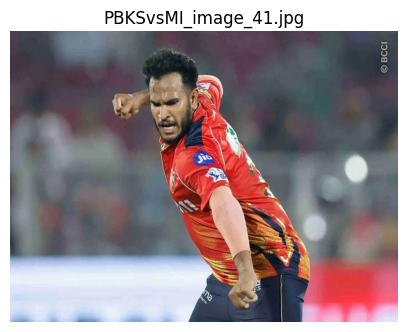

In [8]:
def load_image_bgr(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    if (w, h) != (IMG_W, IMG_H):
        if w < IMG_W or h < IMG_H:
            raise ValueError(f"{os.path.basename(path)}: {w}x{h} below 800x600 - skip (no upscaling).")
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    return img

def grid_cell_bounds(r, c):
    x0, y0 = c * CELL_W, r * CELL_H
    return x0, y0, x0 + CELL_W, y0 + CELL_H

# quick peek at one training image
_demo_path = train_df["_path"].iloc[0]
_demo = load_image_bgr(_demo_path)
plt.figure(figsize=(5,3.8))
plt.imshow(cv2.cvtColor(_demo, cv2.COLOR_BGR2RGB))
plt.title(os.path.basename(_demo_path)); plt.axis("off"); plt.show()

## 4. Lighting-variation augmentation — floodlight V-drop & overexposure

IPL matches vary in floodlight intensity and broadcast exposure. We augment **training** cells via the HSV **V** (brightness) channel:
- **Floodlight V-drop** — multiply V by `<1` (weaker floodlights / shadow / dusk).
- **Overexposure** — raise V with gain `>1`, soft highlight roll-off + mild desaturation (blown-out broadcast).

Our colour features deliberately downweight brightness, so these teach the classifier to lean on hue/chroma & texture, not absolute brightness.

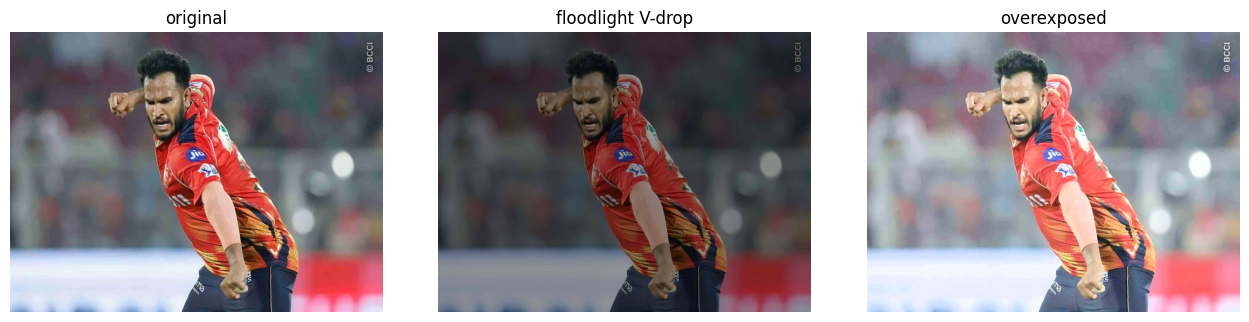

In [9]:
def aug_floodlight_vdrop(bgr, factor=None, rng=None):
    rng = rng or np.random.default_rng()
    factor = factor if factor is not None else float(rng.uniform(0.55, 0.78))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def aug_overexposure(bgr, gain=None, rng=None):
    rng = rng or np.random.default_rng()
    gain = gain if gain is not None else float(rng.uniform(1.25, 1.6))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    v = hsv[..., 2] * gain
    v = 255.0 * (1.0 - np.exp(-v / 200.0)) + 0.15 * v          # soft roll-off
    hsv[..., 2] = np.clip(v, 0, 255)
    hsv[..., 1] *= float(rng.uniform(0.8, 0.95))               # mild desaturation
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def build_cell_augmenters():
    fns = [("orig", lambda x, rng: x)]
    if AUG_FLOODLIGHT_VDROP: fns.append(("vdrop",  lambda x, rng: aug_floodlight_vdrop(x, rng=rng)))
    if AUG_OVEREXPOSURE:     fns.append(("overexp",lambda x, rng: aug_overexposure(x, rng=rng)))
    return fns

# visual sanity check
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a,(t,im) in zip(ax,[("original",_demo),
                        ("floodlight V-drop",aug_floodlight_vdrop(_demo,0.6)),
                        ("overexposed",aug_overexposure(_demo,1.5))]):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 5. Hand-crafted feature extractors

Each operates on one **grid cell** (100×75 BGR patch) and returns a fixed-length vector. The cell feature vector is the concatenation of all enabled blocks. No learned/CNN features anywhere.

In [10]:
def feat_lbp(gray):
    """Uniform LBP histogram - texture, brightness-invariant."""
    lbp = local_binary_pattern(gray, LBP_P, LBP_R, method="uniform")
    n_bins = LBP_P + 2
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    return hist / (hist.sum() + 1e-7)

def feat_hog(gray):
    """HOG - coarse shape/edge structure."""
    g = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)
    return hog(g, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), block_norm="L2-Hys",
               feature_vector=True).astype(np.float32)

def feat_hs(bgr, h_bins=12, s_bins=8):
    """2D Hue-Saturation histogram - colour identity, ignores V."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1], None, [h_bins, s_bins], [0,180,0,256])
    cv2.normalize(hist, hist, 0, 1, cv2.NORM_MINMAX)
    return hist.flatten().astype(np.float32)

def feat_lab(bgr, bins=8):
    """LAB per-channel histograms + colour moments (mean, std, skew)."""
    lab = rgb2lab(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ranges = [(0,100),(-128,127),(-128,127)]
    feats = []
    for ch in range(3):
        x = lab[..., ch].ravel()
        h,_ = np.histogram(x, bins=bins, range=ranges[ch])
        h = h.astype(np.float32); h /= (h.sum()+1e-7)
        mean = x.mean(); std = x.std()+1e-7
        skew = np.mean(((x-mean)/std)**3)
        feats.append(np.concatenate([h, [mean/128.0, std/128.0, skew]]))
    return np.concatenate(feats).astype(np.float32)

def feat_kmeans_dominant(bgr, k=KMEANS_K):
    """K-Means dominant colours: k centroids (RGB-normed) + cluster weights."""
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).reshape(-1,3).astype(np.float32)
    if rgb.shape[0] > 800:
        idx = np.random.default_rng(0).choice(rgb.shape[0], 800, replace=False)
        rgb = rgb[idx]
    km = KMeans(n_clusters=k, n_init=3, random_state=RNG).fit(rgb)
    centers = km.cluster_centers_/255.0
    counts = np.bincount(km.labels_, minlength=k).astype(np.float32)
    weights = counts/(counts.sum()+1e-7)
    order = np.argsort(-weights)
    return np.concatenate([centers[order].ravel(), weights[order]]).astype(np.float32)

def cell_features(bgr_cell):
    gray = cv2.cvtColor(bgr_cell, cv2.COLOR_BGR2GRAY)
    parts = []
    if USE_LBP:    parts.append(feat_lbp(gray))
    if USE_HOG:    parts.append(feat_hog(gray))
    if USE_HS:     parts.append(feat_hs(bgr_cell))
    if USE_LAB:    parts.append(feat_lab(bgr_cell))
    if USE_KMEANS: parts.append(feat_kmeans_dominant(bgr_cell))
    return np.concatenate(parts).astype(np.float32)

_dim = cell_features(_demo[0:CELL_H, 0:CELL_W]).shape[0]
print(f"Per-cell feature vector length: {_dim}")

Per-cell feature vector length: 475


## 6. Build feature matrices from the split

Every grid cell of every image is one sample. Lighting augmentation is applied to **training** images only; test images are featurised as-is. Labels come straight from the `c01..c64` columns of `master.csv`.

In [11]:
def image_to_cell_features(bgr):
    """(64, D) feature matrix for one image, row-major over cells."""
    feats = []
    for r in range(GRID):
        for c in range(GRID):
            x0,y0,x1,y1 = grid_cell_bounds(r,c)
            feats.append(cell_features(bgr[y0:y1, x0:x1]))
    return np.stack(feats, axis=0)

def build_matrix(df, augment=False):
    X, y = [], []
    augmenters = build_cell_augmenters() if augment else [("orig", lambda x,rng:x)]
    rng = np.random.default_rng(RNG)
    skipped = 0
    for _, row in df.iterrows():
        try:
            bgr = load_image_bgr(row["_path"])
        except ValueError as e:
            skipped += 1; continue
        labels = row[CELL_COLS].to_numpy(dtype=np.int64)
        for _, aug_fn in augmenters:
            feats = image_to_cell_features(aug_fn(bgr, rng))
            X.append(feats); y.append(labels)
    if skipped:
        print(f"  (skipped {skipped} under-sized images)")
    return np.concatenate(X, axis=0), np.concatenate(y, axis=0)

print("Featurising TRAIN (with lighting augmentation) ...")
X_train, y_train = build_matrix(train_df, augment=True)
print("Featurising TEST ...")
X_test,  y_test  = build_matrix(test_df, augment=False)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("train class counts:", dict(zip(*[a.tolist() for a in np.unique(y_train, return_counts=True)])))

Featurising TRAIN (with lighting augmentation) ...


KeyboardInterrupt: 

## 7. Model selection & training

Three non-CNN classifiers compared by stratified CV (macro-F1); the best is refit on all training cells. The scaler + classifier are stored as one `Pipeline`.

In [ ]:
candidates = {
    "hgb": Pipeline([
        ("clf", HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.1, l2_regularization=1.0, random_state=RNG)),
    ]),
    "svm": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=8.0, gamma="scale",
                    class_weight="balanced", random_state=RNG)),
    ]),
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=2.0, class_weight="balanced")),
    ]),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)
scores = {}
for name, pipe in candidates.items():
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    scores[name] = s.mean()
    print(f"{name:7s}  CV macro-F1 = {s.mean():.4f} +/- {s.std():.4f}")

best_name = max(scores, key=scores.get)
print("\nBest model:", best_name)
model = candidates[best_name]
model.fit(X_train, y_train)
print("Refit on full training set complete.")

## 8. Evaluation on train & test

In [ ]:
def evaluate(tag, X, y):
    pred = model.predict(X)
    acc = accuracy_score(y, pred); f1m = f1_score(y, pred, average="macro")
    print(f"== {tag} ==  accuracy={acc:.4f}  macro-F1={f1m:.4f}")
    present = sorted(set(y.tolist()) | set(pred.tolist()))
    names = [f"{k}:{LABELS[k]}" for k in present]
    print(classification_report(y, pred, labels=present, target_names=names, zero_division=0))
    return pred

pred_train = evaluate("TRAIN", X_train, y_train)
pred_test  = evaluate("TEST",  X_test,  y_test)

labels_present = sorted(set(y_test.tolist()) | set(pred_test.tolist()))
cm = confusion_matrix(y_test, pred_test, labels=labels_present)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_present))); ax.set_yticks(range(len(labels_present)))
ax.set_xticklabels([LABELS[k] for k in labels_present], rotation=90)
ax.set_yticklabels([LABELS[k] for k in labels_present])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Test confusion matrix")
for i in range(len(labels_present)):
    for j in range(len(labels_present)):
        if cm[i,j]: ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=7)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 9. Save model weights — `model_<teamname>.pkl`

In [ ]:
model_path = f"model_{TEAM_NAME}.pkl"
joblib.dump({
    "model": model, "best_name": best_name, "labels": LABELS,
    "config": {"IMG_W":IMG_W,"IMG_H":IMG_H,"GRID":GRID,"CELL_W":CELL_W,"CELL_H":CELL_H,
               "features":{"LBP":USE_LBP,"HOG":USE_HOG,"HS":USE_HS,"LAB":USE_LAB,"KMEANS":USE_KMEANS},
               "KMEANS_K":KMEANS_K,"LBP_P":LBP_P,"LBP_R":LBP_R},
}, model_path)
print("Saved:", model_path)

## 10. Inference / pipeline code

Reads the saved pickle, accepts a single **test instance** (image path), and returns the 64 per-cell predictions — the "Pipeline Code" deliverable.

In [ ]:
def load_pipeline(path):
    return joblib.load(path)

def predict_image(bundle, image_path):
    """Length-64 list of integer cell labels (row-major c01..c64)."""
    bgr = load_image_bgr(image_path)
    return bundle["model"].predict(image_to_cell_features(bgr)).astype(int).tolist()

_bundle = load_pipeline(model_path)
_sample = test_df["_path"].iloc[0]
_pred = predict_image(_bundle, _sample)
print("Predictions for", os.path.basename(_sample), ":")
print(np.array(_pred).reshape(GRID, GRID))

## 11. Predictions CSV — required output format

One row per image: `Image File Name, Train Or Test, c01 … c64`, values `0–10`. The final model is run on the original (un-augmented) train and test images, one row each, tagged with which split they came from.

In [ ]:
def cells_to_row(image_name, split_tag, preds):
    row = {"Image File Name": image_name, "Train Or Test": split_tag}
    for i in range(N_CELLS):
        row[f"c{i+1:02d}"] = int(preds[i])
    return row

def build_predictions_csv(out_csv="predictions.csv"):
    rows = []
    for df, tag in [(train_df, "Train"), (test_df, "Test")]:
        for _, r in df.iterrows():
            try:
                preds = predict_image(_bundle, r["_path"])
            except ValueError:
                continue   # skipped under-sized image
            rows.append(cells_to_row(os.path.basename(r["_path"]), tag, preds))
    cols = ["Image File Name","Train Or Test"] + [f"c{i+1:02d}" for i in range(N_CELLS)]
    out = pd.DataFrame(rows)[cols]
    out.to_csv(out_csv, index=False)
    print("Wrote", out_csv, "shape", out.shape)
    return out

pred_df = build_predictions_csv("predictions.csv")
pred_df.head()

## 12. Notes

- The notebook reads labels **only** from `data/master.csv` (columns `image, labelled_by, num_players, submitted_by, c01..c64`) and images from `data/images/`. No separate train/test folders are needed — the split is computed in code (`TEST_SIZE`, stratified by each image's dominant team).
- Change `TEAM_NAME` before running. Adjust `TEST_SIZE` / `SPLIT_SEED` to taste.
- Under-sized images (below 800×600) are skipped, not upscaled, per the brief.
- Tune `KMEANS_K`, LBP/HOG params, and the SVM/HGB hyper-parameters once the full labelled set is in.
- For the report/video, document every path taken — including dead-ends — as the guidelines require.